##Loading the data


In [1]:
import pandas as pd

In [2]:
URL = "https://www.kaggle.com/api/v1/datasets/download/hesh97/titanicdataset-traincsv"
train = pd.read_csv(URL, compression = "zip")
train

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [3]:
train.head()
train.shape

(891, 12)

##Cleaning the data

In [4]:
import seaborn as sns

<Axes: >

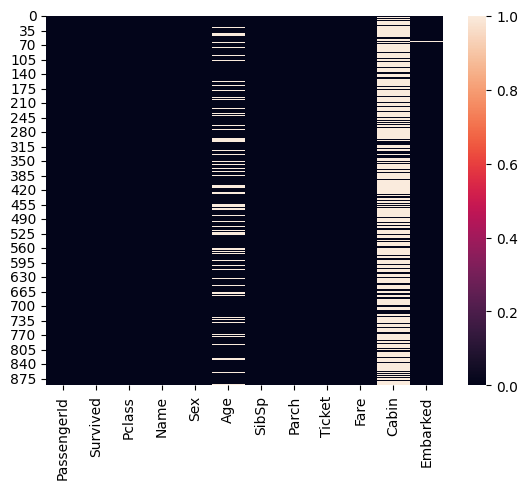

In [5]:
#Let's visualize what columns have null values
sns.heatmap(train.isnull())

In [6]:
#We can also reach the same conclusion with the below
train.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


Reviewing the data, ~20% of the age data is missing. The proportion of age missing
is likely enough for resonable replacement with form of imputation
As for cabin column, it looks like we're missing too much data to do something useful with at a basic level

In [7]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


<Axes: xlabel='Survived', ylabel='count'>

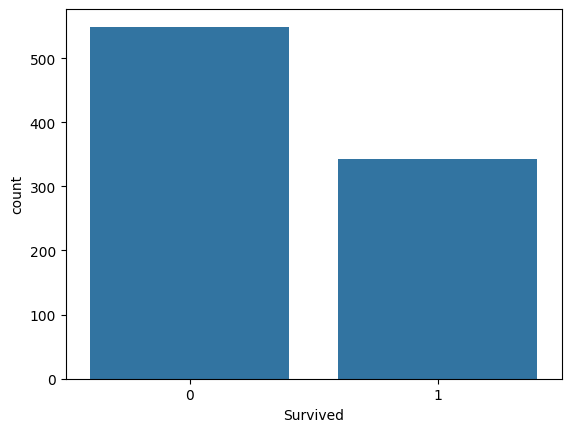

In [8]:
#Check survivor
sns.countplot(data= train, x= "Survived")


<Axes: xlabel='Survived'>

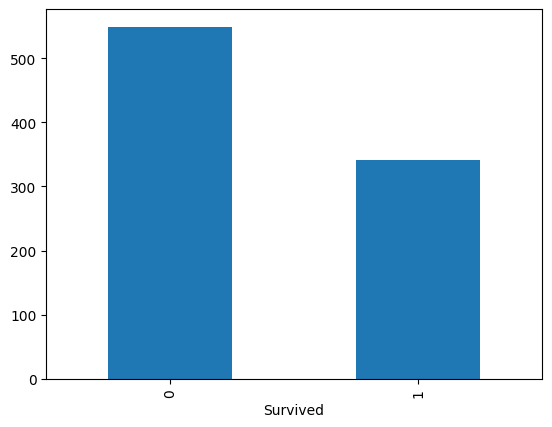

In [9]:
#We can also do this by
train.groupby("Survived")["PassengerId"].count().plot(kind='bar')

<Axes: xlabel='Survived', ylabel='count'>

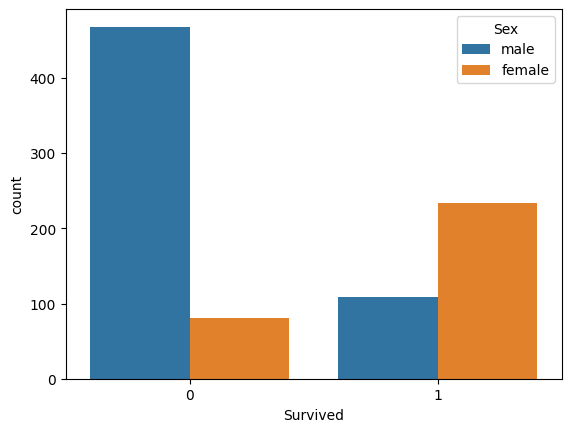

In [10]:
#Check survivors with sex
sns.countplot(data= train, x= "Survived",hue= "Sex")


<Axes: xlabel='Survived', ylabel='count'>

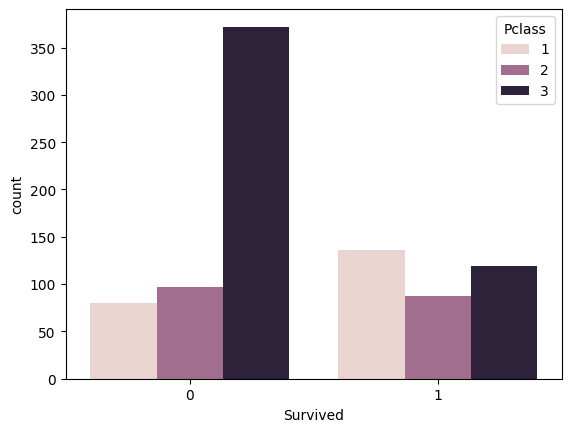

In [11]:
#Check how class played a role in survivors
sns.countplot(data= train, x= "Survived",hue= "Pclass")

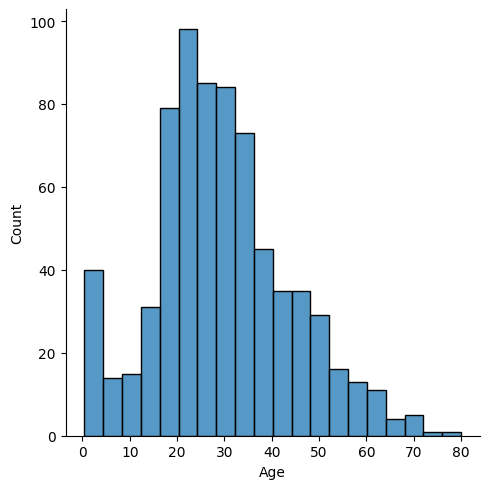

In [12]:
#Check the band of ages of passengers
sns.displot(train["Age"].dropna())

<Axes: xlabel='SibSp', ylabel='count'>

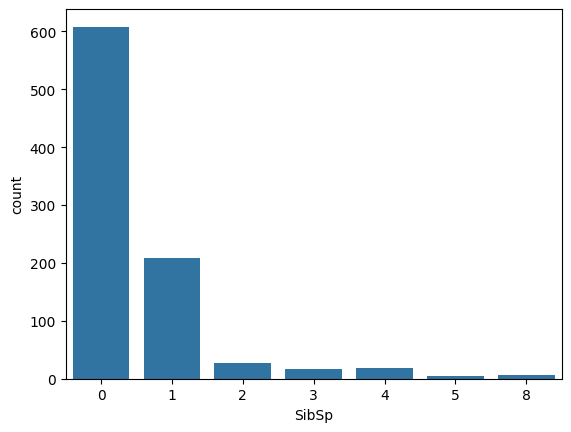

In [13]:
#Check if the passengers had siblings or spouses
sns.countplot(x="SibSp",data= train)

<Axes: xlabel='Pclass', ylabel='Age'>

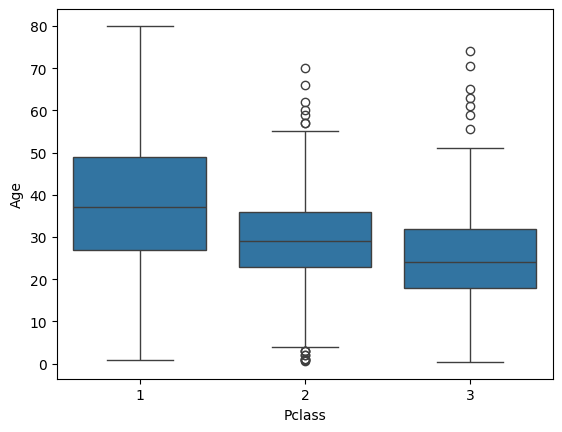

In [14]:
sns.boxplot(x="Pclass",y="Age",data=train)

In [15]:
##We can create a function to apply to every row
def infer_gender(row:pd.Series):
  print(row["PassengerId"])
  print(type(row))
  name = row["Name"].lower()
  if "mr." in name:
    return "M"
  elif "mrs." in name:
    return "F"
  elif "miss." in name:
    return "F"
  elif "rev." in name:
    return "M"
  return pd.NA


In [16]:
#We can utilize the def function by using apply & can store into a column
#train["gender"] = train["Name"].apply(infer_gender)

In [17]:
#On the other hand we can also apply this to a row. In order to do it, use axis =1
train["gender"]= train.apply(infer_gender, axis=1)

1
<class 'pandas.core.series.Series'>
2
<class 'pandas.core.series.Series'>
3
<class 'pandas.core.series.Series'>
4
<class 'pandas.core.series.Series'>
5
<class 'pandas.core.series.Series'>
6
<class 'pandas.core.series.Series'>
7
<class 'pandas.core.series.Series'>
8
<class 'pandas.core.series.Series'>
9
<class 'pandas.core.series.Series'>
10
<class 'pandas.core.series.Series'>
11
<class 'pandas.core.series.Series'>
12
<class 'pandas.core.series.Series'>
13
<class 'pandas.core.series.Series'>
14
<class 'pandas.core.series.Series'>
15
<class 'pandas.core.series.Series'>
16
<class 'pandas.core.series.Series'>
17
<class 'pandas.core.series.Series'>
18
<class 'pandas.core.series.Series'>
19
<class 'pandas.core.series.Series'>
20
<class 'pandas.core.series.Series'>
21
<class 'pandas.core.series.Series'>
22
<class 'pandas.core.series.Series'>
23
<class 'pandas.core.series.Series'>
24
<class 'pandas.core.series.Series'>
25
<class 'pandas.core.series.Series'>
26
<class 'pandas.core.series.Seri

In [18]:
train

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,gender
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,M
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,F
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,F
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,F
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,M
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,M
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,F
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,F
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,M


In [19]:
train[train['gender'].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,gender
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.00,3,1,349909,21.0750,NaN,S,<NA>
16,17,0,3,"Rice, Master. Eugene",male,2.00,4,1,382652,29.1250,NaN,Q,<NA>
30,31,0,1,"Uruchurtu, Don. Manuel E",male,40.00,0,0,PC 17601,27.7208,NaN,C,<NA>
50,51,0,3,"Panula, Master. Juha Niilo",male,7.00,4,1,3101295,39.6875,NaN,S,<NA>
59,60,0,3,"Goodwin, Master. William Frederick",male,11.00,5,2,CA 2144,46.9000,NaN,S,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...
824,825,0,3,"Panula, Master. Urho Abraham",male,2.00,4,1,3101295,39.6875,NaN,S,<NA>
827,828,1,2,"Mallet, Master. Andre",male,1.00,0,2,S.C./PARIS 2079,37.0042,NaN,C,<NA>
831,832,1,2,"Richards, Master. George Sibley",male,0.83,1,1,29106,18.7500,NaN,S,<NA>
850,851,0,3,"Andersson, Master. Sigvard Harald Elias",male,4.00,4,2,347082,31.2750,NaN,S,<NA>


##Data Imputation

Let's define the function to impute the age

In [20]:
#Calculate for average age in each class Pclass 1
float(train[train["Pclass"]==1]["Age"].mean())
#Calculate for average age in each class Pclass 2
float(train[train["Pclass"]==2]["Age"].mean())
#Calculate for average age in each class Pclass 3
float(train[train["Pclass"]==3]["Age"].mean())

25.14061971830986

In [21]:
def impute_age(row):
  age= row["Age"]
  pclass = row["Pclass"]

  if pd.isnull(age):
    #We want to replace the null values & impute it
    if pclass == 1:
      return 37
    elif pclass ==2:
      return 29
    else:
      return 25
  else:
    return age

In [22]:
#####
#def impute_age(cols):
#  Age = cols[0]
#  Pclass = cols[1]
#  if pd.isnull(Age):
#    if Pclass ==1:
#      return 37
#    elif Pclass == 2:
#      return 29
#    else:
#      return 24
#  else:
#    return Age
####


In [23]:
#We then impute the age column to fill in the gaps
train["Age"] = train.apply(impute_age, axis=1)

In [24]:
#We check that the age no longer has null/NaN values
train.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [25]:
#We drop the cabin column & gender
train = train.drop(columns=["gender"])
train.drop(columns=["Cabin"],inplace=True)

In [26]:
#Lastly, we drop all rows that contain NaN values
train.dropna(inplace=True)

##We can get dummy set?

In [27]:
sex = pd.get_dummies(train["Sex"],drop_first=True, dtype=int)


In [28]:
#C = Cherbourg(France) Q= Queenstown (now Cobh, Ireland) S = Southamption (UK)
train["Embarked"].unique()


array(['S', 'C', 'Q'], dtype=object)

In [29]:
embark = pd.get_dummies(train["Embarked"],drop_first=True, dtype=int)
embark

,Q,S
0,0,1
1,0,0
2,0,1
3,0,1
4,0,1
...,...,...
886,0,1
887,0,1
888,0,1
889,0,0


In [30]:
#We drop the remaining columns that are not numeric
train.drop(columns = ["Sex","Embarked","Name","Ticket"], inplace= True)


In [31]:
train

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
0,1,0,3,22.0,1,0,7.2500
1,2,1,1,38.0,1,0,71.2833
2,3,1,3,26.0,0,0,7.9250
3,4,1,1,35.0,1,0,53.1000
4,5,0,3,35.0,0,0,8.0500
...,...,...,...,...,...,...,...
886,887,0,2,27.0,0,0,13.0000
887,888,1,1,19.0,0,0,30.0000
888,889,0,3,25.0,1,2,23.4500
889,890,1,1,26.0,0,0,30.0000


In [32]:
train = pd.concat([train,sex,embark], axis = 1)

In [33]:
embark.shape

(889, 2)

In [34]:
train.shape


(889, 10)

##Logistic Regression

In [35]:
from sklearn.model_selection import train_test_split

In [36]:
X_train,X_test,y_train,y_test = train_test_split(
    train.drop(columns =["Survived"]),
    train["Survived"],
    test_size = 0.30,
    random_state = 101
)
# x =  (the predictor variables) y = (the predicted variable)

In [37]:
X_train

,PassengerId,Pclass,Age,SibSp,Parch,Fare,male,Q,S
807,808,3,18.0,0,0,7.7750,0,0,1
651,652,2,18.0,0,1,23.0000,0,0,1
2,3,3,26.0,0,0,7.9250,0,0,1
690,691,1,31.0,1,0,57.0000,1,0,1
196,197,3,25.0,0,0,7.7500,1,1,0
...,...,...,...,...,...,...,...,...,...
576,577,2,34.0,0,0,13.0000,0,0,1
840,841,3,20.0,0,0,7.9250,1,0,1
338,339,3,45.0,0,0,8.0500,1,0,1
524,525,3,25.0,0,0,7.2292,1,0,0


In [38]:
y_train.shape

(622,)

In [39]:
y_test


,Survived
511,0
613,0
615,1
337,1
718,0
...,...
792,0
828,1
732,0
669,1


In [40]:
train

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,male,Q,S
0,1,0,3,22.0,1,0,7.2500,1,0,1
1,2,1,1,38.0,1,0,71.2833,0,0,0
2,3,1,3,26.0,0,0,7.9250,0,0,1
3,4,1,1,35.0,1,0,53.1000,0,0,1
4,5,0,3,35.0,0,0,8.0500,1,0,1
...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,27.0,0,0,13.0000,1,0,1
887,888,1,1,19.0,0,0,30.0000,0,0,1
888,889,0,3,25.0,1,2,23.4500,0,0,1
889,890,1,1,26.0,0,0,30.0000,1,0,0


In [41]:
from sklearn.linear_model import LogisticRegression
logmodel = LogisticRegression()

In [42]:
logmodel.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [43]:
predictions = logmodel.predict(X_test)

In [44]:
predictions

array([0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1,
       0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0,
       0, 1, 1])

In [46]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.80      0.91      0.85       163
           1       0.81      0.63      0.71       104

    accuracy                           0.80       267
   macro avg       0.81      0.77      0.78       267
weighted avg       0.80      0.80      0.80       267



In [51]:
X_train.columns

Index(['PassengerId', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'male', 'Q',
       'S'],
      dtype='object')

In [52]:
dummy_user = {'PassengerId': 999,
              'Pclass': 3,
              'Age': 19,
              'SibSp': 0,
              'Parch': 0,
              'Fare': 2.0,
              'male': 0,
              'Q': 0,
              'S': 0}
dummy_df = pd.DataFrame([dummy_user])

In [53]:
logmodel.predict(dummy_df)

array([1])

In [54]:
import numpy as np

coef_df = pd.DataFrame({
'feature': train.drop("Survived", axis=1).columns,
'coefficient': logmodel.coef_[0],
'abs_coefficient': np.abs(logmodel.coef_[0])
}).sort_values('abs_coefficient', ascending=False)
coef_df

,feature,coefficient,abs_coefficient
6,male,-2.396099,2.396099
1,Pclass,-0.327152,0.327152
4,Parch,-0.303448,0.303448
7,Q,0.131452,0.131452
8,S,0.081207,0.081207
3,SibSp,-0.049803,0.049803
5,Fare,0.010894,0.010894
2,Age,-0.004667,0.004667
0,PassengerId,0.000855,0.000855
